### *House Price Prediction*
## *Import libraries*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## *Select Features & Target*

In [30]:
X = df.drop(['HousePrice','AveBedrms'], axis=1)
y = df[['MedInc','HouseAge','AveRooms','Population','Latitude','Longitude']]

## *Feature Scaling*

In [31]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

## *Train-Test-Split*

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
     x_scaled, y, test_size=0.2, random_state=42
)

## *Train Multi Models Regression*

In [40]:
models = {
    "Linear Regression" : LinearRegression(),
    "Ridge Regression" : Ridge(),
    "Decision Tree" : DecisionTreeRegressor()
}    

## *Evaluate Model*

In [48]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)   # manual RMSE
    r2 = r2_score(y_test, pred)

    results[name] = {
        "RMSE": rmse,
        "R2 Score": r2
    }

print(results[name])

{'RMSE': np.float64(9.96712339157835), 'R2 Score': 0.3857057138960187}


## *Visualization*

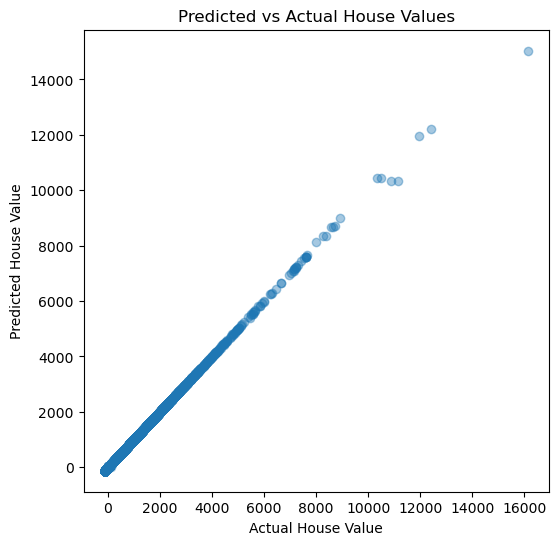

In [53]:
plt.figure(figsize=(6,6))
plt.scatter(x=y_test, y=pred, alpha=0.4)
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Predicted vs Actual House Values")
plt.show()

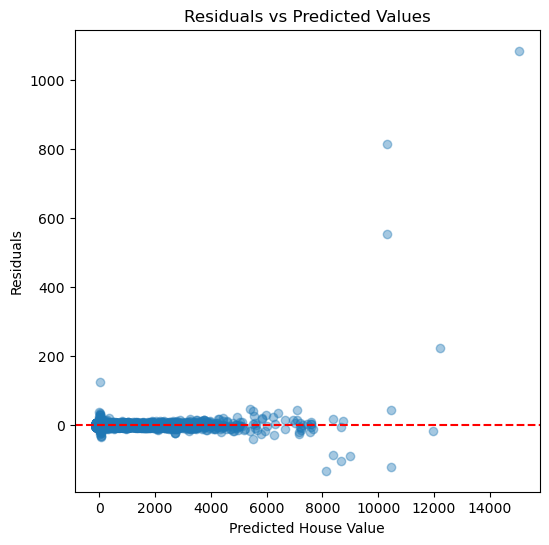

In [54]:
residuals = y_test - pred

plt.figure(figsize=(6,6))
plt.scatter(x=pred, y=residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted House Value")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()
